In [1]:
!pip install xgboost -q

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [16]:
# dataset
df =sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

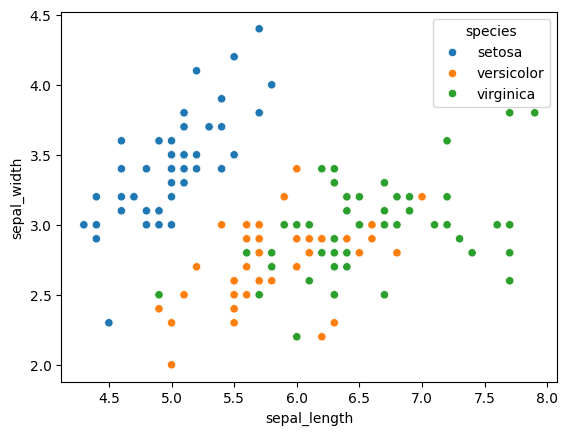

In [17]:
# plot the scatter plot
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df)

In [28]:
# split the data into x and y
x = df.drop('species', axis=1)
y = df['species']

# encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

# split the data into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=101)


In [29]:
%%time
# train the decision tree
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
# predict the data
y_pred = dt.predict(x_test)
# evaluate the model
print('accuracy score: ', accuracy_score(y_test, y_pred))
print('confusion matrix:\\n', confusion_matrix(y_test, y_pred))
print('classification report:\\n', classification_report(y_test, y_pred))
print('recall score: ', recall_score(y_test, y_pred, average='weighted'))
print('f1 score: ', f1_score(y_test, y_pred, average='weighted'))
print('precision score: ', precision_score(y_test, y_pred, average='weighted'))

accuracy score:  0.9666666666666667
confusion matrix:\n [[10  0  0]
 [ 0 12  0]
 [ 0  1  7]]
classification report:\n               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.92      1.00      0.96        12
           2       1.00      0.88      0.93         8

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30

recall score:  0.9666666666666667
f1 score:  0.9662222222222222
precision score:  0.9692307692307692
CPU times: total: 31.2 ms
Wall time: 25.4 ms


In [30]:
%%time
# train the random forest model
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
# predict the data
y_pred = rf.predict(x_test)
# evaluate the model
print('accuracy score: ', accuracy_score(y_test, y_pred))
print('confusion matrix:\\n', confusion_matrix(y_test, y_pred))
print('classification report:\\n', classification_report(y_test, y_pred))
print('recall score: ', recall_score(y_test, y_pred, average='weighted'))
print('f1 score: ', f1_score(y_test, y_pred, average='weighted'))
print('precision score: ', precision_score(y_test, y_pred, average='weighted'))

accuracy score:  1.0
confusion matrix:\n [[10  0  0]
 [ 0 12  0]
 [ 0  0  8]]
classification report:\n               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

recall score:  1.0
f1 score:  1.0
precision score:  1.0
CPU times: total: 250 ms
Wall time: 286 ms


In [32]:
%%time
# train the xgboost model
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
# predict the data
y_pred = xgb.predict(x_test)
# evaluate the model
print('accuracy score: ', accuracy_score(y_test, y_pred))
print('confusion matrix:\\n', confusion_matrix(y_test, y_pred))
print('classification report:\\n', classification_report(y_test, y_pred))
print('recall score: ', recall_score(y_test, y_pred, average='weighted'))
print('f1 score: ', f1_score(y_test, y_pred, average='weighted'))
print('precision score: ', precision_score(y_test, y_pred, average='weighted'))

accuracy score:  0.9333333333333333
confusion matrix:\n [[10  0  0]
 [ 0 12  0]
 [ 0  2  6]]
classification report:\n               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.86      1.00      0.92        12
           2       1.00      0.75      0.86         8

    accuracy                           0.93        30
   macro avg       0.95      0.92      0.93        30
weighted avg       0.94      0.93      0.93        30

recall score:  0.9333333333333333
f1 score:  0.9311355311355312
precision score:  0.9428571428571428
CPU times: total: 453 ms
Wall time: 151 ms


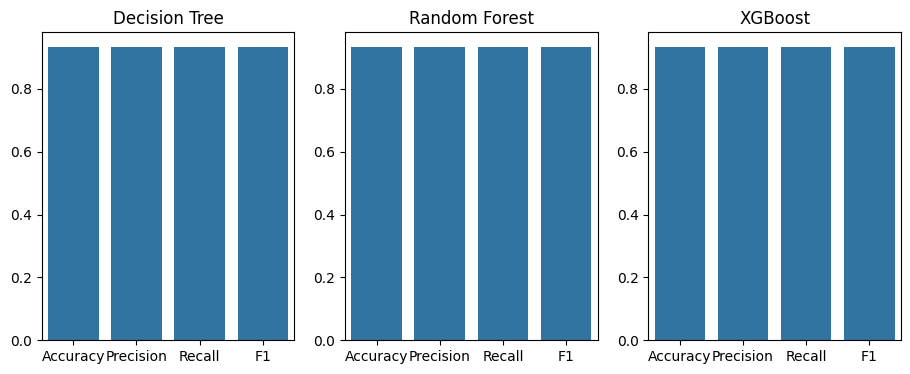

In [33]:
# make a bar plot showing each of the matrix with respect to the model
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('Decision Tree')
plt.subplot(1, 4, 2)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('Random Forest')
plt.subplot(1, 4, 3)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('XGBoost')
# plt.tight_layout()
plt.show()